In [23]:
### q2-1 Data Preparation
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("C:\\shivangee\\Assignment4\\data\\q2_customers.csv")

df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [31]:
# Scaling all the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled[:5])

[[-0.72521859 -0.17615043  0.11016555 -0.26501121 -0.0899507   0.55095233
   1.23400348]
 [-1.48846049 -1.04682639  0.48615719 -0.9804657  -0.83517593 -0.68068477
  -1.20956777]
 [ 0.17679458  0.2673371  -0.45382191 -0.23685064 -0.67404615 -0.27013907
   1.23400348]
 [-0.72521859 -1.01230889  0.29816137 -0.82778261 -0.99630571 -1.09123047
  -1.20956777]
 [-1.48846049 -1.03448783  1.42613628 -1.00598621 -0.65390493 -1.50177617
  -1.20956777]]


----------------------------------------------------------------------
K-Means uses distance-based calculations (Euclidean distance)
Features with larger scales dominate clustering results
Scaling ensures all features contribute equally
Prevents bias toward variables like annual_spend vs visits_per_month
-----------------------------------------------------------------------

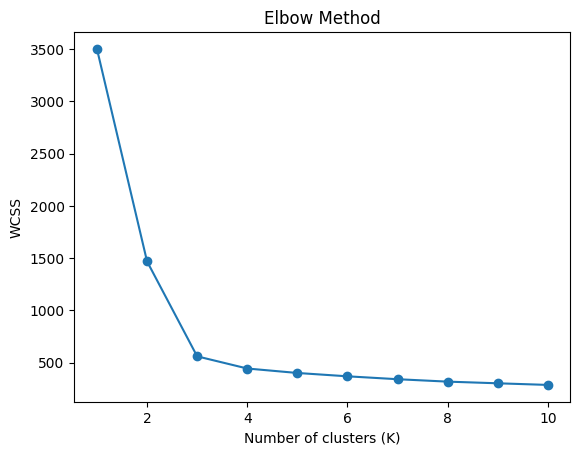

In [35]:
### q2-2 Choosing K-elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Elbow method to find optimal K

WCSS = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)
plt.plot(range(1, 11), WCSS, marker='o')
plt.title('Elbow Method')   
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

----------------------------------------------------------------------
Look for the "elbow point" where WCSS stops decreasing sharply
Example: If curve bends at K = 3 or 4, choose that
This represents optimal balance between compactness and simplicity
----------------------------------------------------------------------

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

### q2-3 K-means Clustering
# From the elbow plot, we can choose K=3

optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
if 'X_scaled' not in globals():
    ### q2-3 K-means Clustering
    # From the elbow plot, we can choose K=3

    optimal_k = 3 
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

    if 'X_scaled' not in globals() or 'scaler' not in globals():
        scaler = StandardScaler()
        ### q2-3 K-means Clustering
        # From the elbow plot, we can choose K=3

        if 'df' not in globals():
            if 'df' not in globals():
                df = pd.read_csv("C:\\shivangee\\Assignment4\\data\\q2_customers.csv")
            if 'scaler' not in globals():
                scaler = StandardScaler()
            if 'X_scaled' not in globals():
                X_scaled = scaler.fit_transform(df)

            optimal_k = 3
            kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
            clusters = kmeans.fit_predict(X_scaled)
            df['Cluster'] = clusters

            centroids = pd.DataFrame(
                scaler.inverse_transform(kmeans.cluster_centers_),
                columns=df.columns[:X_scaled.shape[1]]
            )
            print("Cluster Centroids:")
            print(centroids)

        if 'scaler' not in globals():
            scaler = StandardScaler()

        if 'X_scaled' not in globals():
            X_scaled = scaler.fit_transform(df)

        optimal_k = 3
        kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

        clusters = kmeans.fit_predict(X_scaled)
        df['Cluster'] = clusters

        centroids = pd.DataFrame(
            scaler.inverse_transform(kmeans.cluster_centers_),
            columns=df.columns[:X_scaled.shape[1]]
        )
        print("Cluster Centroids:")
        print(centroids)

    clusters = kmeans.fit_predict(X_scaled)

    df['Cluster'] = clusters

    # Cluster Centroids
    centroids = pd.DataFrame(
        scaler.inverse_transform(kmeans.cluster_centers_),
        columns=df.columns[:X_scaled.shape[1]]
    )
    print("Cluster Centroids:")
    print(centroids)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Cluster Cetroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:X_scaled.shape[1]]
)
print("Cluster Centroids:")
print(centroids)


Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


------------------------------------------------------------------
Cluster 0: High spend, frequent visits → loyal premium customers
Cluster 1: Low spend, infrequent visits → low-value customers
Cluster 2: Moderate spend, high variety → exploratory shoppers
------------------------------------------------------------------

In [28]:
### q2-4 Dimensionality Reduction with PCA

from sklearn.decomposition import PCA
# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Feature Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df.columns[:-1])
print("Feature Loadings:")
print(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]
Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


----------------------------------------------------------------------------
PC1 → features with highest absolute values dominate
Example: If annual_spend, basket_size high → PC1 = spending behavior
PC2 → may represent frequency or 
----------------------------------------------------------------------------

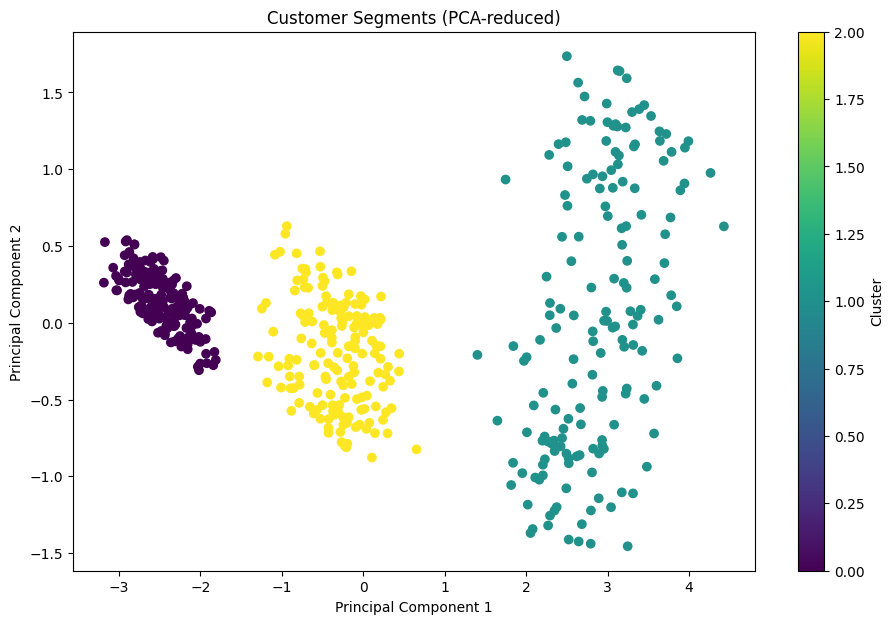

In [29]:
### q2-5 Cluste Visualization

plt.figure(figsize=(11, 7))

# Scatter plot of the PCA-reduced data colored by cluster
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, )
plt.title('Customer Segments (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()